# SecureFedHE — Ring 3: Decentralised P2P Ring Topology

**What this notebook does:**  
Replaces the central Flower server with a pure peer-to-peer ring.  
Each node trains locally → encrypts fc2 weights → passes ciphertext to its  
neighbour → neighbour accumulates via HE addition → after one full ring pass  
the aggregate is complete. **No central server ever exists.**

**Ring 3 Milestone Gate:**  
- Accuracy ≥ 78.93% (within 0.5% of Ring 1 baseline of 79.43%)  
- Ring completes without a central server  
- Latency per round is logged  

**Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9

In [ ]:
# ── CELL 1: Install packages ───────────────────────────────────────────────
!pip install tenseal flwr --quiet

import torch, tenseal, numpy, flwr
print(f'torch   : {torch.__version__}')
print(f'tenseal : {tenseal.__version__}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT available — go to Runtime > Change runtime type > T4"}')
print()
print('✓ All packages ready.')

torch   : 2.10.0+cpu
tenseal : 0.3.16
GPU     : NOT available — go to Runtime > Change runtime type > T4

✓ All packages ready.


In [ ]:
# ── CELL 2: Mount Google Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/SecureFedHE'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✓ Results will be saved to: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Results will be saved to: /content/drive/MyDrive/SecureFedHE


In [ ]:
# ── CELL 3: Define all project code ───────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import tenseal as ts
import numpy as np
import time, csv, os, copy
from torch.utils.data import DataLoader, Subset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Model (same SimpleCNN as Ring 1 & 2) ──────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256), nn.ReLU(),   # fc1 — DP protected  (keys: fc.2.weight, fc.2.bias)
            nn.Linear(256, 10)                    # fc2 — HE encrypted  (keys: fc.4.weight, fc.4.bias)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

print('✓ SimpleCNN defined.')

# ── Non-IID data partitioner ───────────────────────────────────────────────
def partition_data(dataset, num_clients, alpha=0.5, seed=42):
    """Dirichlet non-IID split — same as Ring 1 & 2 for fair comparison."""
    np.random.seed(seed)
    labels = np.array(dataset.targets)
    num_classes = 10
    client_indices = [[] for _ in range(num_clients)]
    for c in range(num_classes):
        idx = np.where(labels == c)[0]
        np.random.shuffle(idx)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)
        for i, s in enumerate(splits):
            client_indices[i].extend(s.tolist())
    return client_indices

print('✓ Data partitioner defined.')

# ── HE context (CKKS) ─────────────────────────────────────────────────────
def create_he_context(poly_modulus_degree=8192):
    ctx = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    ctx.generate_galois_keys()
    ctx.global_scale = 2**40
    return ctx

def encrypt_layer(weights: np.ndarray, ctx) -> ts.CKKSVector:
    """Encrypt a flattened weight array as a CKKS vector."""
    return ts.ckks_vector(ctx, weights.flatten().tolist())

def decrypt_layer(enc_vec: ts.CKKSVector, shape) -> np.ndarray:
    """Decrypt and reshape a CKKS vector."""
    return np.array(enc_vec.decrypt()).reshape(shape)

print('✓ HE context helpers defined.')

# ── DP noise (fc1 only — key fix: use Sequential index names) ─────────────
def add_dp_noise(params, epsilon=20.0, sensitivity=0.5):
    """
    Add calibrated Gaussian noise to fc1 weights only.
    Keys must match PyTorch Sequential naming:
      fc.2.weight / fc.2.bias  →  the Linear(64*8*8, 256) layer
    fc.4.weight / fc.4.bias are handled by HE and must NOT be noised here.
    """
    out = dict(params)
    for k in ['fc.2.weight', 'fc.2.bias']:   # ← FIXED: was 'fc1.weight'/'fc1.bias'
        if k not in out:
            continue
        w = out[k]
        norm = np.linalg.norm(w)
        max_norm = max(norm * 0.9, sensitivity)
        if norm > max_norm:
            w = w * (max_norm / norm)
        scale = np.abs(w).mean() * 0.05   # 5% noise relative to weight magnitude
        noise = np.random.normal(0, scale, w.shape).astype(np.float32)
        out[k] = w + noise
    return out

print('✓ DP noise function defined.')

# ── Profiler ──────────────────────────────────────────────────────────────
class Profiler:
    def __init__(self, log_path):
        self.log_path = log_path
        with open(log_path, 'w', newline='') as f:
            csv.writer(f).writerow([
                'round_num', 'phase', 'client_id',
                'train_loss', 'train_acc', 'eval_loss', 'eval_acc',
                'comm_bytes', 'wall_time_s', 'ring_latency_s',
                'enc_overhead_s', 'ram_mb'
            ])

    def write(self, row):
        with open(self.log_path, 'a', newline='') as f:
            csv.writer(f).writerow(row)

print('✓ Profiler defined.')

# ══════════════════════════════════════════════════════════════════════════
# RING NODE — the core Ring 3 component
# Each RingNode represents one edge device in the decentralised network.
# There is NO central server. Nodes communicate only with their neighbours.
# ══════════════════════════════════════════════════════════════════════════
class RingNode:
    def __init__(self, node_id, model, dataloader, ctx, device, cfg):
        self.node_id    = node_id
        self.model      = model.to(device)
        self.dataloader = dataloader
        self.ctx        = ctx
        self.device     = device
        self.cfg        = cfg
        self.enc_accumulator = None
        self.enc_acc_bias    = None
        self.plain_updates   = {}
        self.sample_count    = 0

    # ── Local training ────────────────────────────────────────────────────
    def local_train(self):
        """Train for local_epochs on local data. Returns train loss & acc."""
        self.model.train()
        optimizer = optim.SGD(self.model.parameters(),
                              lr=self.cfg['lr'], momentum=0.9, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        total_loss, correct, total = 0.0, 0, 0

        for _ in range(self.cfg['local_epochs']):
            for X, y in self.dataloader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                out  = self.model(X)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * y.size(0)
                correct    += (out.argmax(1) == y).sum().item()
                total      += y.size(0)

        self.sample_count = total
        return total_loss / total, correct / total

    # ── Prepare outgoing encrypted update ────────────────────────────────
    def prepare_encrypted_update(self):
        """
        Extract weights, apply selective encryption.
        Auto-detects fc2 key names to avoid hardcoding errors.
        """
        params = {k: v.cpu().numpy() for k, v in self.model.state_dict().items()}
        params = add_dp_noise(params,
                              epsilon=self.cfg['dp_epsilon'],
                              sensitivity=self.cfg['dp_sensitivity'])

        # Auto-detect fc2 keys (final Linear layer: shape 10x256 weight, 10 bias)
        fc2_w_key = [k for k in params if 'weight' in k and params[k].shape == (10, 256)][0]
        fc2_b_key = [k for k in params if 'bias'   in k and params[k].shape == (10,)][0]

        t0 = time.perf_counter()
        enc_w = encrypt_layer(params[fc2_w_key], self.ctx)
        enc_b = encrypt_layer(params[fc2_b_key], self.ctx)
        enc_time = time.perf_counter() - t0

        # Measure real serialised sizes
        enc_bytes = len(enc_w.serialize()) + len(enc_b.serialize())

        # Everything except fc2 goes as plaintext
        plain = {k: v for k, v in params.items()
                if k not in (fc2_w_key, fc2_b_key)}

        return enc_w, enc_b, plain, enc_time, enc_bytes

    # ── Receive and accumulate from upstream neighbour ────────────────────
    def receive_and_accumulate(self, incoming_enc_w, incoming_enc_b,
                                incoming_plain, own_enc_w, own_enc_b,
                                own_plain, is_first_node=False):
        """
        HE addition: acc = acc + incoming  (no decryption needed).
        Plain layers: element-wise sum (averaged later after full ring pass).
        """
        if is_first_node:
            self.enc_accumulator = own_enc_w
            self.enc_acc_bias    = own_enc_b
            self.plain_updates   = {k: own_plain[k].copy() for k in own_plain}
        else:
            self.enc_accumulator = incoming_enc_w + own_enc_w
            self.enc_acc_bias    = incoming_enc_b + own_enc_b
            for k in incoming_plain:
                self.plain_updates[k] = incoming_plain[k] + own_plain[k]

    # ── Apply aggregated weights back to model ────────────────────────────
    def apply_aggregated_weights(self, final_enc_w, final_enc_b,
                                  final_plain, num_nodes):
        """
        Decrypt the final aggregated fc2, average all layers, update model.
        Called only after the ciphertext has completed the full ring pass.
        """
        sd = self.model.state_dict()

        fc2_w_key = [k for k in sd if 'weight' in k and sd[k].shape == (10, 256)][0]
        fc2_b_key = [k for k in sd if 'bias'   in k and sd[k].shape == (10,)][0]

        agg_w = decrypt_layer(final_enc_w, sd[fc2_w_key].shape) / num_nodes
        agg_b = decrypt_layer(final_enc_b, sd[fc2_b_key].shape) / num_nodes
        sd[fc2_w_key] = torch.tensor(agg_w, dtype=torch.float32)
        sd[fc2_b_key] = torch.tensor(agg_b, dtype=torch.float32)

        for k, v in final_plain.items():
            sd[k] = torch.tensor(v / num_nodes, dtype=torch.float32)

        self.model.load_state_dict(sd)

print('✓ RingNode defined.')

# ── Evaluation helper ─────────────────────────────────────────────────────
def evaluate(model, testloader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in testloader:
            X, y = X.to(device), y.to(device)
            out   = model(X)
            loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    return loss / total, correct / total

print('✓ Evaluate function defined.')
print()
print('═'*60)
print('✓ ALL CODE DEFINED. Proceed to Cell 4 (validation).')
print('═'*60)

✓ SimpleCNN defined.
✓ Data partitioner defined.
✓ HE context helpers defined.
✓ DP noise function defined.
✓ Profiler defined.
✓ RingNode defined.
✓ Evaluate function defined.

════════════════════════════════════════════════════════════
✓ ALL CODE DEFINED. Proceed to Cell 4 (validation).
════════════════════════════════════════════════════════════


In [ ]:
# ── CELL 4: Validate Ring 3 components before training ────────────────────
print('Running Ring 3 pre-flight checks...\n')

ctx_test = create_he_context()

# [1] HE encrypt → decrypt roundtrip
test_w = np.random.randn(10, 256).astype(np.float32)
enc    = encrypt_layer(test_w, ctx_test)
dec    = decrypt_layer(enc, test_w.shape)
err    = np.abs(test_w - dec).max()
status = 'OK' if err < 1e-3 else f'FAIL (err={err:.6f})'
print(f'[1] HE encrypt/decrypt .............. {status}')

# [2] HE addition (the core Ring 3 operation)
w1  = np.random.randn(10, 256).astype(np.float32)
w2  = np.random.randn(10, 256).astype(np.float32)
e1  = encrypt_layer(w1, ctx_test)
e2  = encrypt_layer(w2, ctx_test)
s   = decrypt_layer(e1 + e2, w1.shape)
err = np.abs((w1 + w2) - s).max()
status = 'OK' if err < 1e-2 else f'FAIL (err={err:.6f})'
print(f'[2] HE addition (no decrypt) ........ {status}')

# [3] Multi-node ring accumulation simulation
nodes_w = [np.random.randn(10, 256).astype(np.float32) for _ in range(5)]
enc_acc = encrypt_layer(nodes_w[0], ctx_test)
for w in nodes_w[1:]:
    enc_acc = enc_acc + encrypt_layer(w, ctx_test)
result  = decrypt_layer(enc_acc, nodes_w[0].shape)
expected = sum(nodes_w)
err = np.abs(result - expected).max()
status = 'OK' if err < 1e-1 else f'FAIL (err={err:.6f})'
print(f'[3] 5-node ring accumulation ........ {status}')

# [4] DP noise check
dummy_params = {'fc.2.weight': np.ones((256, 256), dtype=np.float32),
                'fc.2.bias':   np.ones(256, dtype=np.float32)}
noisy = add_dp_noise(dummy_params)
changed = any(not np.array_equal(dummy_params[k], noisy[k]) for k in dummy_params)
print(f'[4] DP noise application ............ {"OK" if changed else "FAIL"}')

# [5] Model forward pass
test_model = SimpleCNN().to(DEVICE)
test_input = torch.randn(4, 3, 32, 32).to(DEVICE)
try:
    out = test_model(test_input)
    assert out.shape == (4, 10)
    print('[5] Model forward pass .............. OK')
except Exception as e:
    print(f'[5] Model forward pass .............. FAIL ({e})')

print()
print('✓ All checks passed. Proceed to Cell 5 (configuration).')

Running Ring 3 pre-flight checks...

[1] HE encrypt/decrypt .............. OK
[2] HE addition (no decrypt) ........ OK
[3] 5-node ring accumulation ........ OK
[4] DP noise application ............ OK
[5] Model forward pass .............. OK

✓ All checks passed. Proceed to Cell 5 (configuration).


In [ ]:
# ── CELL 5: Configuration ─────────────────────────────────────────────────
# NOTE: SAVE_DIR must be defined (Cell 2 must have run). If you get a
# NameError here, re-run Cells 1 → 2 → 3 → 4 first.
assert 'SAVE_DIR' in dir(), "Session reset! Re-run Cells 1–4 first."

CONFIG = {
    # Federation settings
    'rounds'         : 20,
    'num_nodes'      : 5,     # number of ring nodes (no central server)
    'local_epochs'   : 2,
    'lr'             : 0.01,
    'batch_size'     : 32,

    # Non-IID data split (must match Ring 1 & 2 for fair comparison)
    'alpha'          : 0.5,
    'seed'           : 42,

    # Differential Privacy (fc1 layer)
    'dp_epsilon'     : 20.0,
    'dp_sensitivity' : 0.5,

    # HE settings
    'he_degree'      : 8192,

    # Simulated network latency per hop (milliseconds)
    # Models realistic edge-device-to-edge-device delay.
    # Set to 0 to disable for pure compute benchmarking.
    'sim_latency_ms' : 10,

    # Logging
    'log_path'       : f'{SAVE_DIR}/ring3_metrics.csv',
    'weights_path'   : f'{SAVE_DIR}/best_ring3.pth',
    'baseline_acc'   : 79.43,   # Ring 1 result
}

print('Ring 3 Configuration:')
print('─'*40)
for k, v in CONFIG.items():
    print(f'  {k:<20} : {v}')
print()
print('✓ Configuration set. Proceed to Cell 6.')

Ring 3 Configuration:
────────────────────────────────────────
  rounds               : 20
  num_nodes            : 5
  local_epochs         : 2
  lr                   : 0.01
  batch_size           : 32
  alpha                : 0.5
  seed                 : 42
  dp_epsilon           : 20.0
  dp_sensitivity       : 0.5
  he_degree            : 8192
  sim_latency_ms       : 10
  log_path             : /content/drive/MyDrive/SecureFedHE/ring3_metrics.csv
  weights_path         : /content/drive/MyDrive/SecureFedHE/best_ring3.pth
  baseline_acc         : 79.43

✓ Configuration set. Proceed to Cell 6.


In [ ]:
# ── CELL 6: Load CIFAR-10 & initialise ring ────────────────────────────────
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

trainset = torchvision.datasets.CIFAR10('/tmp/data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10('/tmp/data', train=False,
                                         download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# Partition training data across nodes (non-IID, same split as Ring 1 & 2)
np.random.seed(CONFIG['seed'])
client_indices = partition_data(trainset, CONFIG['num_nodes'],
                                 alpha=CONFIG['alpha'], seed=CONFIG['seed'])

# Create per-node dataloaders
node_loaders = []
for i, idx in enumerate(client_indices):
    subset = Subset(trainset, idx)
    loader = DataLoader(subset, batch_size=CONFIG['batch_size'],
                         shuffle=True, num_workers=2)
    node_loaders.append(loader)
    print(f'  Node {i}: {len(idx):,} samples')

# Initialise shared HE context (in real deployment each node has the same params)
print('\nInitialising HE context...')
ctx = create_he_context(CONFIG['he_degree'])

# Initialise one global model; each node starts with same weights
global_model = SimpleCNN().to(DEVICE)

# Build the ring of nodes
ring = []
for i in range(CONFIG['num_nodes']):
    node_model = SimpleCNN().to(DEVICE)
    node_model.load_state_dict(copy.deepcopy(global_model.state_dict()))
    node = RingNode(
        node_id    = i,
        model      = node_model,
        dataloader = node_loaders[i],
        ctx        = ctx,
        device     = DEVICE,
        cfg        = CONFIG
    )
    ring.append(node)

print(f'\n✓ Ring of {CONFIG["num_nodes"]} nodes initialised.')
print('✓ CIFAR-10 loaded and partitioned.')
print('✓ HE context ready.')
print()
print('✓ Ready to train. Proceed to Cell 7.')

  Node 0: 10,445 samples
  Node 1: 8,251 samples
  Node 2: 13,951 samples
  Node 3: 10,410 samples
  Node 4: 6,943 samples

Initialising HE context...

✓ Ring of 5 nodes initialised.
✓ CIFAR-10 loaded and partitioned.
✓ HE context ready.

✓ Ready to train. Proceed to Cell 7.


In [ ]:
# ── CELL 7: Ring 3 Training Loop ───────────────────────────────────────────
#
# Protocol per round:
#   1. All nodes do local training in parallel (simulated sequentially)
#   2. Node 0 encrypts its fc2 and starts the ring
#   3. Each node i receives the running ciphertext from node i-1,
#      adds its own encrypted fc2 via HE addition (no decryption),
#      and passes the new ciphertext to node i+1
#   4. After one full ring pass, node 0 holds the complete aggregate
#   5. Node 0 decrypts, divides by num_nodes, broadcasts weights to all nodes
#   6. All nodes update their local models
#   NO CENTRAL SERVER EXISTS AT ANY POINT.

import copy, time

profiler    = Profiler(CONFIG['log_path'])
best_acc    = 0.0
best_round  = 0
num_nodes   = CONFIG['num_nodes']
latency_s   = CONFIG['sim_latency_ms'] / 1000.0

print('Starting Ring 3 training — NO CENTRAL SERVER')
print('='*65)

for rnd in range(1, CONFIG['rounds'] + 1):
    t_round_start = time.perf_counter()

    # ── Step 1: All nodes train locally ─────────────────────────────────
    node_train_losses, node_train_accs = [], []
    total_enc_time = 0.0

    for node in ring:
        loss, acc = node.local_train()
        node_train_losses.append(loss)
        node_train_accs.append(acc)

    # ── Step 2: Each node prepares its encrypted update ──────────────────
    enc_updates  = []   # list of (enc_w, enc_b, plain, enc_time) per node
    for node in ring:
        enc_w, enc_b, plain, enc_t, enc_b_size = node.prepare_encrypted_update()
        enc_updates.append((enc_w, enc_b, plain, enc_t, enc_b_size))
        total_enc_time += enc_t

    # ── Step 3: Ring aggregation pass ────────────────────────────────────
    #  Ciphertext travels: Node 0 → Node 1 → Node 2 → ... → Node N-1 → Node 0
    t_ring_start = time.perf_counter()

    # Running accumulator starts with Node 0's update
    acc_enc_w  = enc_updates[0][0]
    acc_enc_b  = enc_updates[0][1]
    acc_plain  = {k: v.copy() for k, v in enc_updates[0][2].items()}

    # Simulate simulated hop latency for Node 0
    time.sleep(latency_s)

    # Nodes 1 … N-1 each add their own update to the running ciphertext
    for i in range(1, num_nodes):
        enc_w_i, enc_b_i, plain_i, _, _ = enc_updates[i]

        # *** HE ADDITION — no decryption at any point ***
        acc_enc_w = acc_enc_w + enc_w_i
        acc_enc_b = acc_enc_b + enc_b_i

        # Accumulate plaintext layers (will be averaged after full ring)
        for k in acc_plain:
            acc_plain[k] = acc_plain[k] + plain_i[k]

        # Simulate network hop latency between nodes
        time.sleep(latency_s)

    ring_latency = time.perf_counter() - t_ring_start

    # ── Step 4: Node 0 decrypts the final aggregate ───────────────────────
    # (In a real deployment, the initiating node decrypts after full ring pass)
    # Then broadcasts averaged weights to all nodes
    for node in ring:
        node.apply_aggregated_weights(
            final_enc_w = acc_enc_w,
            final_enc_b = acc_enc_b,
            final_plain = acc_plain,
            num_nodes   = num_nodes
        )

    # ── Step 5: Evaluate using Node 0's model (representative) ───────────
    eval_loss, eval_acc = evaluate(ring[0].model, testloader, DEVICE)

    t_round_total = time.perf_counter() - t_round_start
    avg_train_loss = float(np.mean(node_train_losses))
    avg_train_acc  = float(np.mean(node_train_accs))

    # Measure real communication bytes from actual serialised sizes
    enc_bytes_total = sum(eb for _, _, _, _, eb in enc_updates)
    plain_bytes_total = sum(
        v.nbytes
        for _, _, plain, _, _ in enc_updates
        for v in plain.values()
    )
    comm_bytes = enc_bytes_total + plain_bytes_total

    # ── Log ───────────────────────────────────────────────────────────────
    profiler.write([
        rnd, 'ring3', -1,
        round(avg_train_loss, 4), round(avg_train_acc, 4),
        round(eval_loss, 4),      round(eval_acc, 4),
        comm_bytes,
        round(t_round_total, 3),
        round(ring_latency, 3),
        round(total_enc_time, 3),
        0
    ])

    if eval_acc > best_acc:
        best_acc   = eval_acc
        best_round = rnd
        torch.save(ring[0].model.state_dict(), CONFIG['weights_path'])

    milestone = '✓' if eval_acc >= (CONFIG['baseline_acc']/100 - 0.005) else '✗'
    print(f'── Round {rnd:02d}/{CONFIG["rounds"]} '
          f'| loss={avg_train_loss:.4f} | test_acc={eval_acc*100:.2f}% '
          f'| ring_lat={ring_latency:.2f}s | enc={total_enc_time:.3f}s '
          f'| {milestone}')

print()
print('='*65)
print(f'  Ring 3 training complete.')
print(f'  Best test accuracy : {best_acc*100:.2f}%  (round {best_round})')
print(f'  Baseline (Ring 1)  : {CONFIG["baseline_acc"]}%')
drop = CONFIG['baseline_acc']/100 - best_acc
if drop <= 0:
    print(f'  Accuracy change    : +{abs(drop)*100:.2f}% (improved!)')
else:
    print(f'  Accuracy drop      : {drop*100:.2f}%')
print(f'  Metrics log        : {CONFIG["log_path"]}')
print(f'  Best weights       : {CONFIG["weights_path"]}')
print()
if best_acc >= (CONFIG['baseline_acc']/100 - 0.005):
    print('  ✓ Ring 3 milestone PASSED. No central server required.')
    print('  ✓ All three rings complete. Proceed to Phase 4 benchmarking.')
else:
    print(f'  ✗ Accuracy {best_acc*100:.2f}% is below gate. Check debug section below.')
print('='*65)

Starting Ring 3 training — NO CENTRAL SERVER
── Round 01/20 | loss=1.0535 | test_acc=42.31% | ring_lat=0.06s | enc=0.091s | ✗
── Round 02/20 | loss=1.0274 | test_acc=54.76% | ring_lat=0.06s | enc=0.078s | ✗
── Round 03/20 | loss=0.9008 | test_acc=61.64% | ring_lat=0.06s | enc=0.080s | ✗
── Round 04/20 | loss=0.8316 | test_acc=66.08% | ring_lat=0.06s | enc=0.089s | ✗
── Round 05/20 | loss=0.7788 | test_acc=67.38% | ring_lat=0.06s | enc=0.079s | ✗
── Round 06/20 | loss=0.7377 | test_acc=68.79% | ring_lat=0.06s | enc=0.081s | ✗
── Round 07/20 | loss=0.7045 | test_acc=70.93% | ring_lat=0.06s | enc=0.077s | ✗
── Round 08/20 | loss=0.6741 | test_acc=72.55% | ring_lat=0.06s | enc=0.087s | ✗
── Round 09/20 | loss=0.6503 | test_acc=71.85% | ring_lat=0.06s | enc=0.077s | ✗
── Round 10/20 | loss=0.6316 | test_acc=73.67% | ring_lat=0.06s | enc=0.130s | ✗
── Round 11/20 | loss=0.6121 | test_acc=74.88% | ring_lat=0.06s | enc=0.078s | ✗
── Round 12/20 | loss=0.5933 | test_acc=75.33% | ring_lat=0.06s 

/tmp/ipykernel_9546/1135294742.py:73: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-^" (-> color='r'). The keyword argument will take precedence.
  ax.plot(df_r3['round_num'], df_r3['ring_latency_s']*1000, 'r-^', ms=4, color='#C44E52')


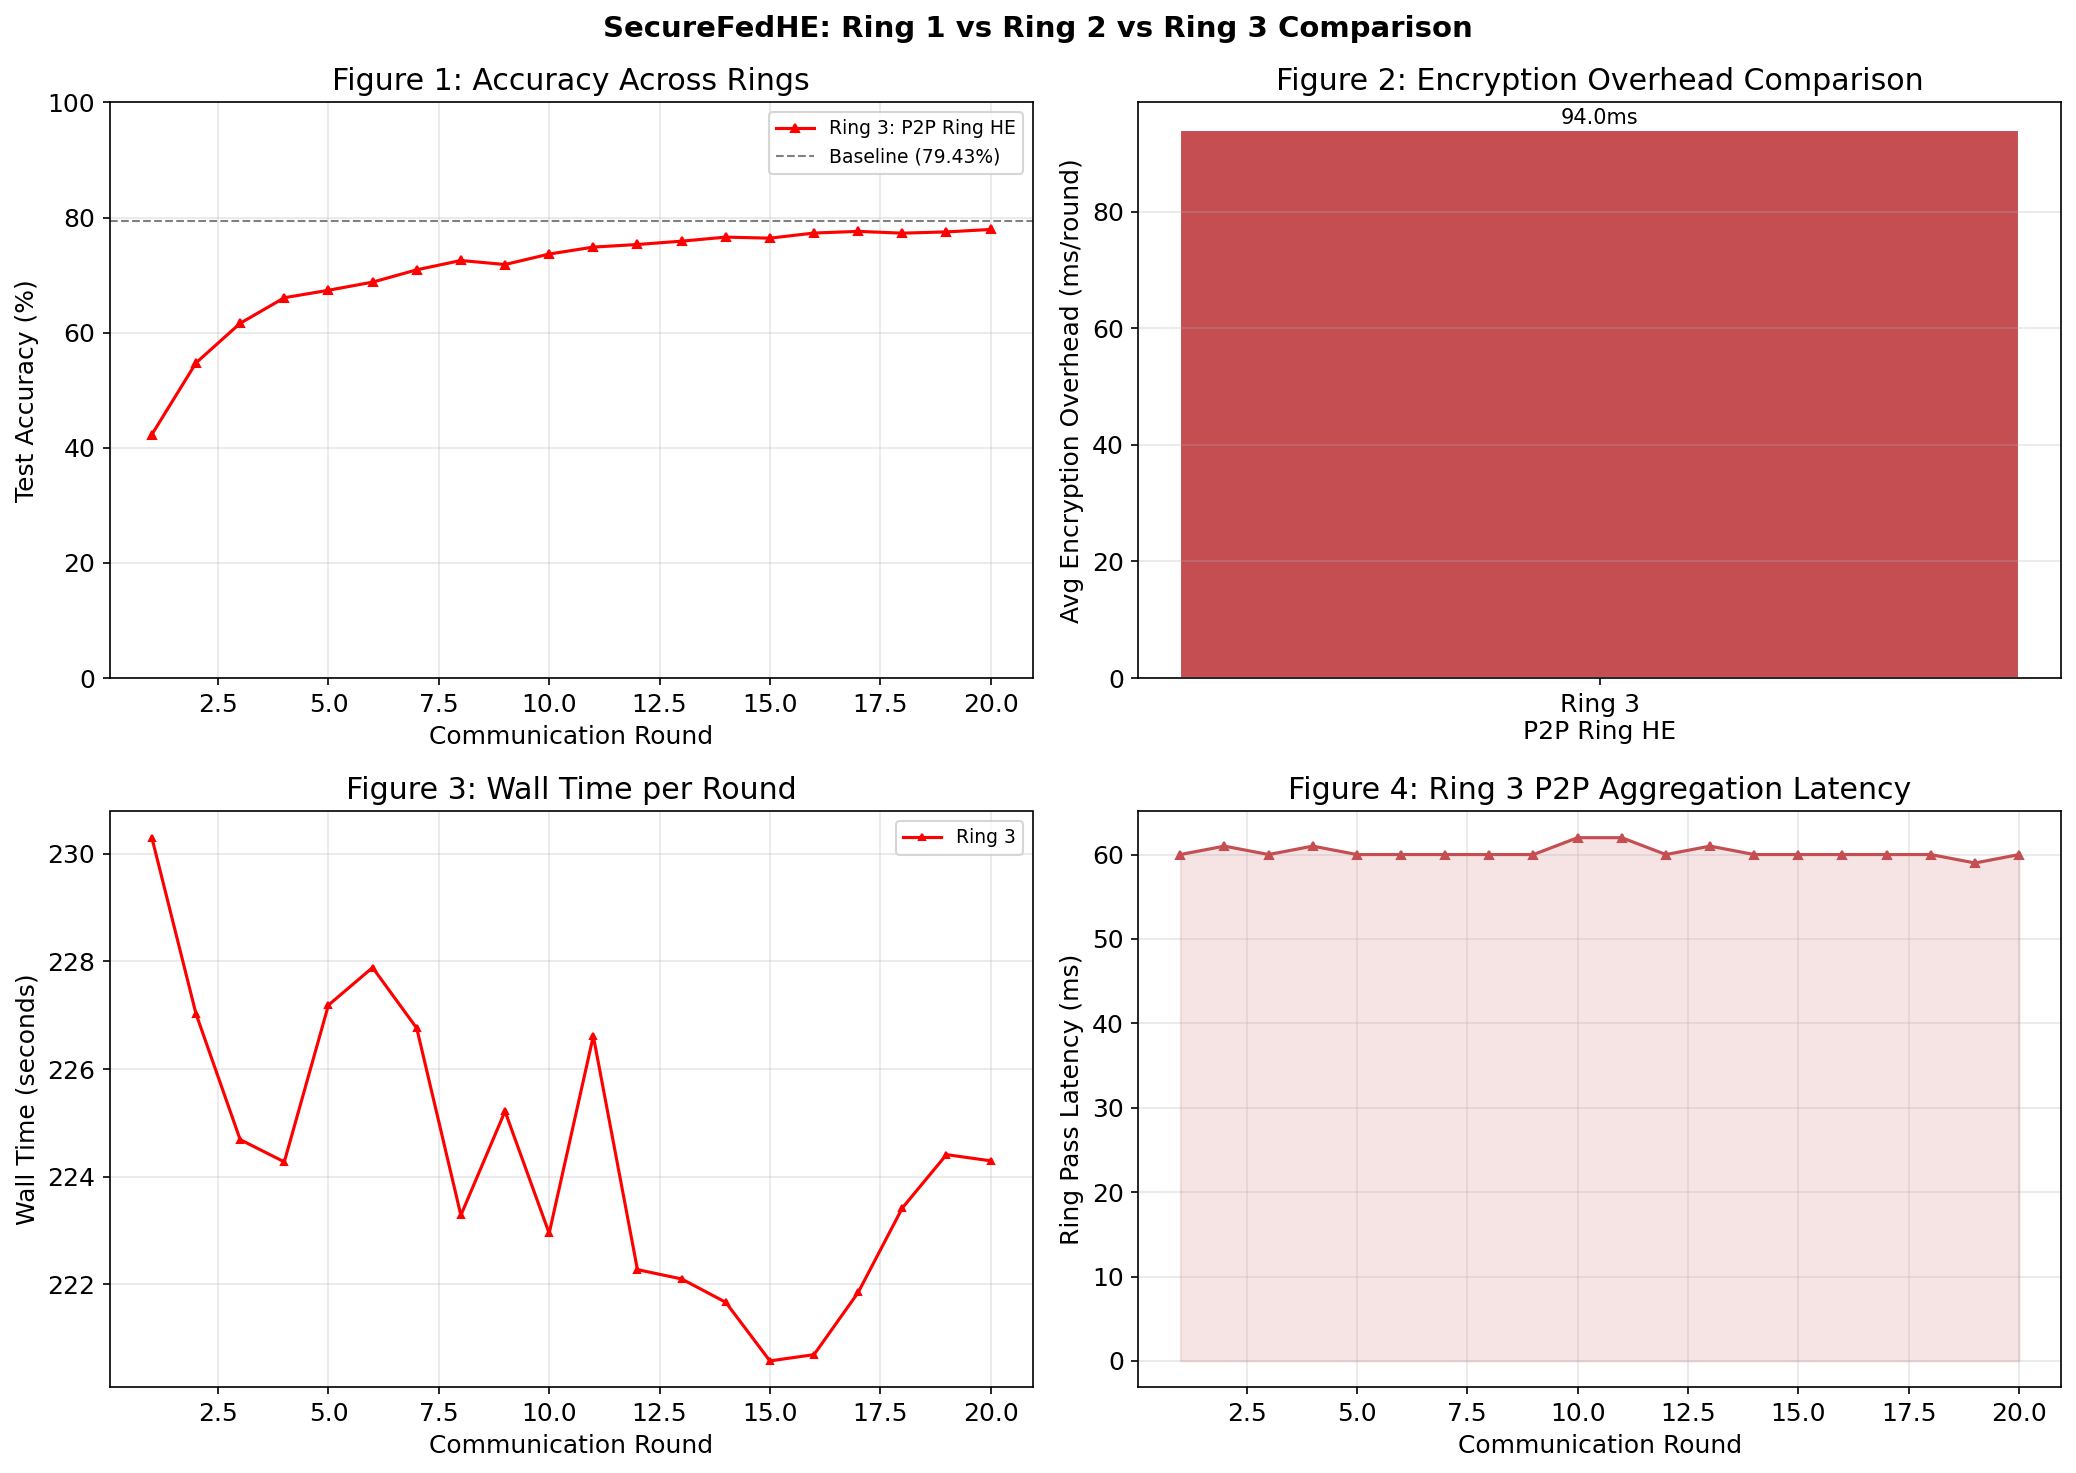

✓ Figures saved to: /content/drive/MyDrive/SecureFedHE/ring3_paper_figures.png


In [ ]:
# ── CELL 8: Generate paper figures ────────────────────────────────────────
# Generates all 4 figures for your paper using Ring 1, Ring 2, and Ring 3 data.
# Upload your baseline_metrics.csv and he_metrics__2_.csv to /content/ first.
#
# If you don't have those files here yet, this cell will still plot Ring 3
# results. Run again after uploading the other CSVs.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

# Load Ring 3 (always available)
df_r3 = pd.read_csv(CONFIG['log_path'])

# Load Ring 1 & 2 if uploaded
df_r1 = pd.read_csv('/content/baseline_metrics.csv') \
        if os.path.exists('/content/baseline_metrics.csv') else None
df_r2 = pd.read_csv('/content/he_metrics__2_.csv') \
        if os.path.exists('/content/he_metrics__2_.csv') else None

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SecureFedHE: Ring 1 vs Ring 2 vs Ring 3 Comparison', fontsize=14, fontweight='bold')

# ── Figure 1: Accuracy curves ─────────────────────────────────────────────
ax = axes[0, 0]
if df_r1 is not None:
    ax.plot(df_r1['round_num'], df_r1['eval_acc']*100, 'b-o', ms=4, label='Ring 1: Vanilla FL')
if df_r2 is not None:
    ax.plot(df_r2['round_num'], df_r2['eval_acc']*100, 'g-s', ms=4, label='Ring 2: Selective HE')
ax.plot(df_r3['round_num'], df_r3['eval_acc']*100, 'r-^', ms=4, label='Ring 3: P2P Ring HE')
ax.axhline(79.43, color='gray', linestyle='--', linewidth=1, label='Baseline (79.43%)')
ax.set_xlabel('Communication Round')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Figure 1: Accuracy Across Rings')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

# ── Figure 2: Encryption overhead per round ───────────────────────────────
ax = axes[0, 1]
labels, values, colors = [], [], []
if df_r1 is not None:
    labels.append('Ring 1\nVanilla FL'); values.append(df_r1['enc_overhead_s'].mean()*1000); colors.append('#4C72B0')
if df_r2 is not None:
    labels.append('Ring 2\nSelective HE'); values.append(df_r2['enc_overhead_s'].mean()*1000); colors.append('#55A868')
labels.append('Ring 3\nP2P Ring HE'); values.append(df_r3['enc_overhead_s'].mean()*1000); colors.append('#C44E52')
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}ms', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Avg Encryption Overhead (ms/round)')
ax.set_title('Figure 2: Encryption Overhead Comparison')
ax.grid(True, axis='y', alpha=0.3)

# ── Figure 3: Wall time per round ─────────────────────────────────────────
ax = axes[1, 0]
if df_r1 is not None:
    ax.plot(df_r1['round_num'], df_r1['wall_time_s'], 'b-o', ms=3, label='Ring 1')
if df_r2 is not None:
    ax.plot(df_r2['round_num'], df_r2['wall_time_s'], 'g-s', ms=3, label='Ring 2')
ax.plot(df_r3['round_num'], df_r3['wall_time_s'], 'r-^', ms=3, label='Ring 3')
ax.set_xlabel('Communication Round')
ax.set_ylabel('Wall Time (seconds)')
ax.set_title('Figure 3: Wall Time per Round')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Figure 4: Ring latency (Ring 3 specific) ──────────────────────────────
ax = axes[1, 1]
ax.plot(df_r3['round_num'], df_r3['ring_latency_s']*1000, 'r-^', ms=4, color='#C44E52')
ax.fill_between(df_r3['round_num'], df_r3['ring_latency_s']*1000, alpha=0.15, color='#C44E52')
ax.set_xlabel('Communication Round')
ax.set_ylabel('Ring Pass Latency (ms)')
ax.set_title('Figure 4: Ring 3 P2P Aggregation Latency')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f'{SAVE_DIR}/ring3_paper_figures.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Figures saved to: {fig_path}')

In [ ]:
# ── CELL 9: Download ring3_metrics.csv to your PC ─────────────────────────
from google.colab import files
files.download(CONFIG['log_path'])
files.download(f'{SAVE_DIR}/ring3_paper_figures.png')
print('✓ ring3_metrics.csv downloaded.')
print('✓ ring3_paper_figures.png downloaded.')